In [487]:
from pathlib import Path
import lib_config as config

import os
import json
import numpy as np
import pandas as pd

import lib_gp
import lib_backbone
import lib_plot as plot

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [488]:
_config = config._loadConfig(Path("./_config.toml"))
app_config = config.initParams(_config, debug=True)


[Io]
  filename_input      : params.csv
  filename_output     : results.csv
  filename_temp       : temp_hfss_export.csv

[Sim]
  n_simulation        : 100
  n_repeats           : 1
  n_init              : 20
  kernel_type         : RBF
  n_params            : 8
  length_scale        : 1.000000
  noise_std           : 0.010000
  noise_var           : 0.000100
  lower_bounds        : [0.1, 0.4, 0.1, 0.4, 0.1, 0.4, 0.1, 0.4]
  upper_bounds        : [0.215, 0.85, 0.215, 0.85, 0.215, 0.85, 0.215, 0.85]
  param_names         : ['s1x', 's1y', 's2x', 's2y', 's3x', 's3y', 's4x', 's4y']

[Hfss]
  n_simulation        : 100
  n_repeats           : 1
  n_init              : 20
  n_params            : 8
  lower_bounds        : [0.1, 0.4, 0.1, 0.4, 0.1, 0.4, 0.1, 0.4]
  upper_bounds        : [0.215, 0.85, 0.215, 0.85, 0.215, 0.85, 0.215, 0.85]
  param_names         : ['s1x', 's1y', 's2x', 's2y', 's3x', 's3y', 's4x', 's4y']

[Test]
  n_simulation        : 500
  n_repeats           : 1
  n_init      

In [489]:
if app_config.sim.n_simulation <= app_config.sim.n_init:
    raise ValueError("n_simulation must be greater than n_init.")
        

In [490]:
backbone= lib_backbone.Backbone(config = app_config)
gp = lib_gp.GaussianProcess(config = app_config)

base_dir = app_config.env.dir_base
backbone.initStorer()

Created new run directory: T:\RAkizawa\HFSS_C2R\1124190124
HDF5 dataset created at: T:\RAkizawa\HFSS_C2R\1124190124\results.h5


In [491]:
_config_temp = {
"filename_input": _config["io"]["filename_input"],
"filename_output": _config["io"]["filename_output"],
"n_simulation": _config["sim"]["n_simulation"],
"n_repeats": _config["sim"]["n_repeats"],
"param_names": _config["sim"]["param_names"],
"WATCH_DIR": str(backbone._get_dir_run()),
"INPUT_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_input"])),
"RESULTS_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_output"])),
"TEMP_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"])),
}

In [492]:
with open(base_dir / Path("_config_HFSS.json"), 'w') as f:
        json.dump(_config_temp , f, indent=4)

print(f"Temporarily updated '{base_dir / Path("_config_HFSS.json")}' with run-specific WATCH_DIR for HFSS.")

Temporarily updated 'T:\RAkizawa\HFSS_C2R\_config_HFSS.json' with run-specific WATCH_DIR for HFSS.


In [493]:
def getResult(input_params, param_names, temp_hfss_path, result_file_path):
    df_temp = pd.read_csv(temp_hfss_path)
    header_flag = not os.path.exists(result_file_path)
    
    try:
        s11_value = df_temp.iloc[-1, -1]
        result_row = dict(zip(param_names, input_params))
        result_row["S11"] = s11_value

        print(result_row)
        df_result = pd.DataFrame([result_row])
        df_result.to_csv(result_file_path, mode='a', header=header_flag, index=False)
        print(f"[Success] Result saved. S11: {s11_value}")

        try:
            os.remove(temp_hfss_path)
        except OSError:
            pass
        return True
        
    
    except Exception as e:
        print(f"[Error][getResult] Failed to process result: {e}")
        return False

In [494]:
RESULTS_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_output"]))
TEMP_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"]))

In [ ]:
# --- A. HFSS ---
def target_hfss(_config_temp, sim_id, param_names, params):
    backbone.call_subroutine(_config_temp, sim_id, param_names, params)
    getResult(params, param_names, TEMP_FILE, RESULTS_FILE)
    df_result = pd.read_csv(RESULTS_FILE)
    return df_result.iloc[-1]['S11'] # <--- should be defined as objective param

# --- B. Synthetic Test Function ---
def target_ackley(_config_temp, sim_id, param_names, params):
    
    n_params = app_config.sim.n_params 
    
    # --- 2. Calculation ---
    x = np.array(params)
    n = float(n_params)

    arg1 = -0.2 * np.sqrt((1.0/n) * np.sum(x**2))
    arg2 = (1.0/n) * np.sum(np.cos(2. * np.pi * x))
    
    y = -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e
    
    # --- 3. Saving data ---
    result_row = dict(zip(param_names, params))
    
    result_row['S11'] = y
    
    # Define column order
    columns_order = param_names + ['S11']
    
    # Write to CSV
    header_flag = not os.path.exists(RESULTS_FILE) # if file does not exis, set column names
    df_result = pd.DataFrame([result_row], columns=columns_order)
    df_result.to_csv(RESULTS_FILE, mode='a', header=header_flag, index=False)
    
    return y

costFunction = target_hfss
costFunction = target_ackley

# =====================================
if costFunction == target_hfss:
    cfg = app_config.hfss
elif costFunction == target_ackley:
    cfg = app_config.test

LOWER_BOUNDS = cfg.lower_bounds
UPPER_BOUNDS = cfg.lower_bounds
PARAM_NAMES = cfg.param_names
N_REPT = cfg.n_repeats
N_INIT = cfg.n_init
N_OPTM = cfg.n_simulation - cfg.n_init


In [496]:
def costFucntionWrapper(_config_temp, param_names, params,):

    params = np.array(params).flatten()
    sim_id = backbone._getSimulationID()
    
    y = costFunction(_config_temp, sim_id, param_names, params,)
    
    print(f" > Step {sim_id}: y = {y:.3f} params={params}")
    
    # logging here

    return y

In [497]:
# Optimizer
def optGaussianProcess(n_optm, result_file, lower_bound, upper_bound):

    acq_values = np.full(N_OPTM, np.nan) 
        
    for i in range(n_optm):
        
        # Gaussian Process
        df_current = pd.read_csv(result_file)
        X_sample = df_current[PARAM_NAMES].values
        y_sample = df_current[['S11']].values
        
        length_scale, K, Ky, Ky_inv, hyp = gp.run_gp(X_sample, y_sample)

        # Expected Improvement Search
        x_next, ei = gp.getExpectedImprovement(X_sample, y_sample, Ky_inv, length_scale, lower_bound, upper_bound, dims=len(upper_bound))

        print(f"  > Point with max EI ({ei:.4f}) found.")

        acq_values[i] = ei

        costFucntionWrapper(_config_temp, PARAM_NAMES, x_next,)

    return acq_values



Starting GP Repeat 1/1

--- Generating 20 Initial LHS Samples ---
wrote 20 rows x 2 cols to input_LHS
 > Step 1: y = 12.289 params=[10.98969443  0.12867575]
 > Step 2: y = 19.457 params=[24.77587151 18.77576443]
 > Step 3: y = 9.541 params=[3.56222541 6.0501583 ]
 > Step 4: y = 16.413 params=[13.9155475  12.56382302]
 > Step 5: y = 19.581 params=[-21.87411146  22.51210779]
 > Step 6: y = 19.257 params=[-27.8344383  12.8955249]
 > Step 7: y = 7.352 params=[ 2.02794741 -4.30687307]
 > Step 8: y = 14.615 params=[-11.69362766   9.05817912]
 > Step 9: y = 13.890 params=[  7.66687643 -10.95706817]
 > Step 10: y = 20.218 params=[-29.33190802 -22.14799046]
 > Step 11: y = 19.150 params=[ 18.21033694 -23.18813054]
 > Step 12: y = 16.483 params=[-13.26054457 -13.88724741]
 > Step 13: y = 18.790 params=[-18.08285255  21.2183058 ]
 > Step 14: y = 19.985 params=[ 20.27028833 -29.07267454]
 > Step 15: y = 20.695 params=[28.23436601 29.42867084]
 > Step 16: y = 16.284 params=[ -0.13190564 -19.035937

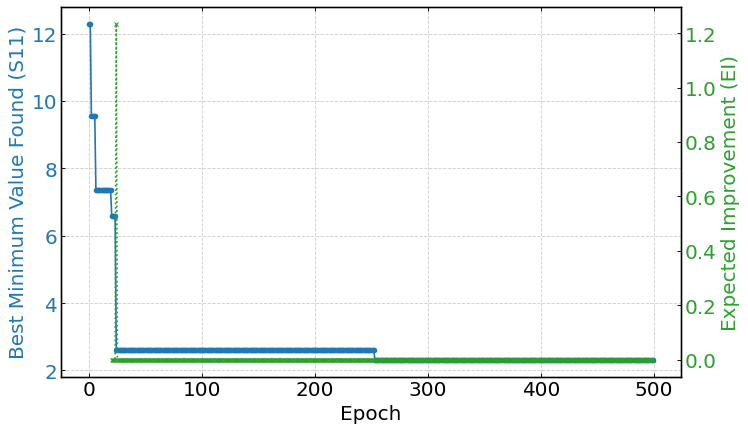

In [498]:
try:
    
    # --- Outer loop for each independent repeat ---
    for r in range(N_REPT):
        backbone.printn(f"Starting GP Repeat {r + 1}/{N_REPT}")
        
        # -------------------- initial simulation --------------------------------
        backbone.printn(f"--- Generating {N_INIT} Initial LHS Samples ---")
        X_initial = backbone.LHSsampler(dims = cfg.n_params, lower_bounds=current_lower_bounds, upper_bounds=current_upper_bounds)
        # --- save to df ---
        df_input = pd.DataFrame(X_initial, columns=PARAM_NAMES)
        # --- save to HDF ---
        backbone._addNewDatasetToHDF(df_input, "input", "input_LHS")
        
        for i in range(N_INIT):
            params = X_initial[i]
            costFucntionWrapper(_config_temp, PARAM_NAMES, params,)
        # -------------------- initial simulation --------------------------------
        backbone.printn(f"\n--- Initial {N_INIT} simulations complete for Repeat {r+1}. ---")
        # --- PHASE 2: Active Learning Loop for this repeat ---
        final_gp_model = {}
        
        acq_values = optGaussianProcess(N_OPTM, RESULTS_FILE, current_lower_bounds, current_upper_bounds)

        # ==============================================================================
        # 5. Visualize Final Model
        # ==============================================================================
        
        # --- After each repeat, archive results and save plot data ---
        backbone.printn(f"--- Processing Results for Repeat {r+1} ---")
        df_current = pd.read_csv(RESULTS_FILE)
        df_output = backbone._genOutputDataFrame(df_current, acq_values)
        # save
        backbone._addNewDatasetToHDF(df_output, "output", f"repeat_{r+1}")
        
        # --- 5a. Visualize learning curve of the final model ---
        plot.plot_learning_curve(df_output)
                
finally:
    json_file = base_dir / Path("_config_HFSS.json")
    json_file.unlink(missing_ok=True) # delite the json file
    if backbone.h5f:
        backbone.h5f.close()



In [499]:
df_current = pd.read_csv(RESULTS_FILE)
X_sample = df_current[PARAM_NAMES].values
y_sample = df_current[['S11']].values

backbone.printn(f"Updating GP model with all {len(df_current)} samples for visualization...")
final_length_scale, K_final, Ky_final, Ky_final_inv, res_hyper = gp.run_gp(X_sample, y_sample)
final_gp_model = {
    "length_scale": final_length_scale,
    "K": K_final,
    "Ky": Ky_final,
    "Ky_inv": Ky_final_inv,
    "opt": res_hyper,
}


# ==============================================================================
# 7. Global Search on Final Surrogate Model using Differential Evolution
# ==============================================================================
backbone.printn(" Performing Global Search on Final Surrogate Model using DE")
plot.differential_evolution_lcb(df_output, app_config.sim.param_names, app_config.sim.lower_bounds, app_config.sim.upper_bounds, 100, 200, 0.8, 0.8, 2.0, 101, final_gp_model["Ky_inv"], final_gp_model["length_scale"])



Updating GP model with all 500 samples for visualization...
  > Loaded 500 data points for GP model training.
  > Optimizing GP hyperparameters...
  > Optimized Length Scale: 3.2770

 Performing Global Search on Final Surrogate Model using DE


KeyError: "['s2x', 's2y', 's3x', 's3y', 's4x', 's4y'] not in index"

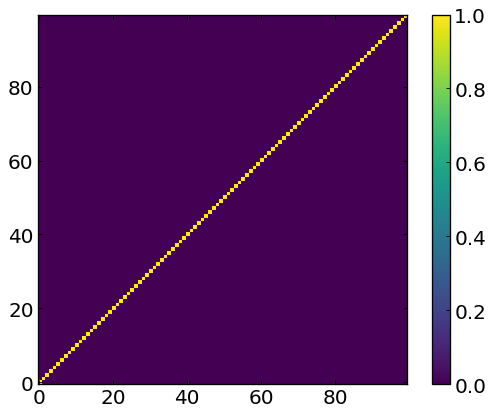

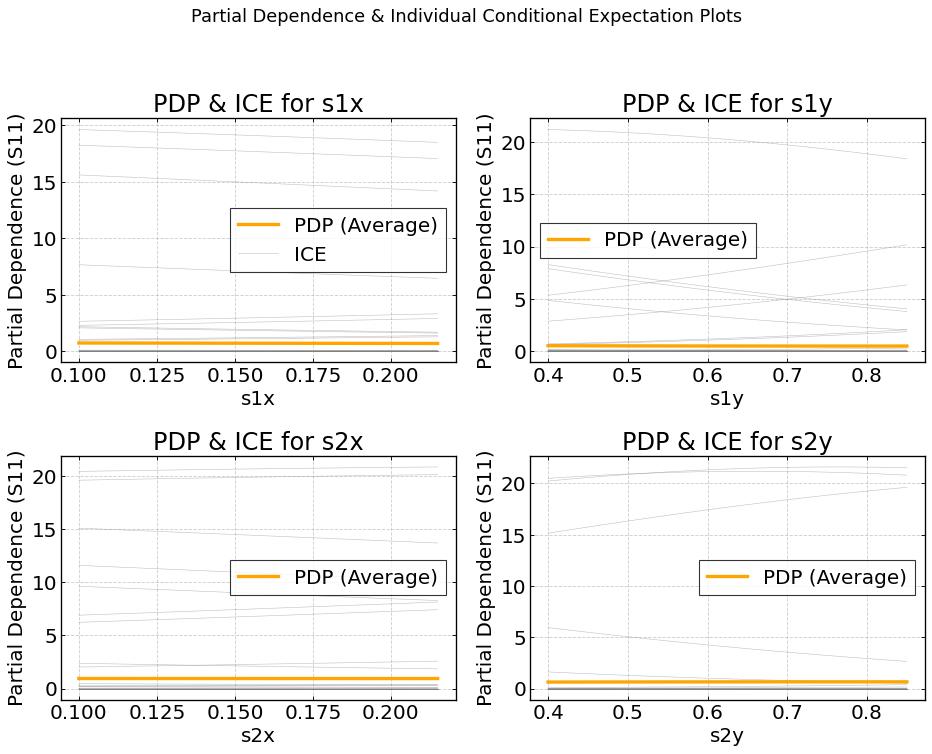

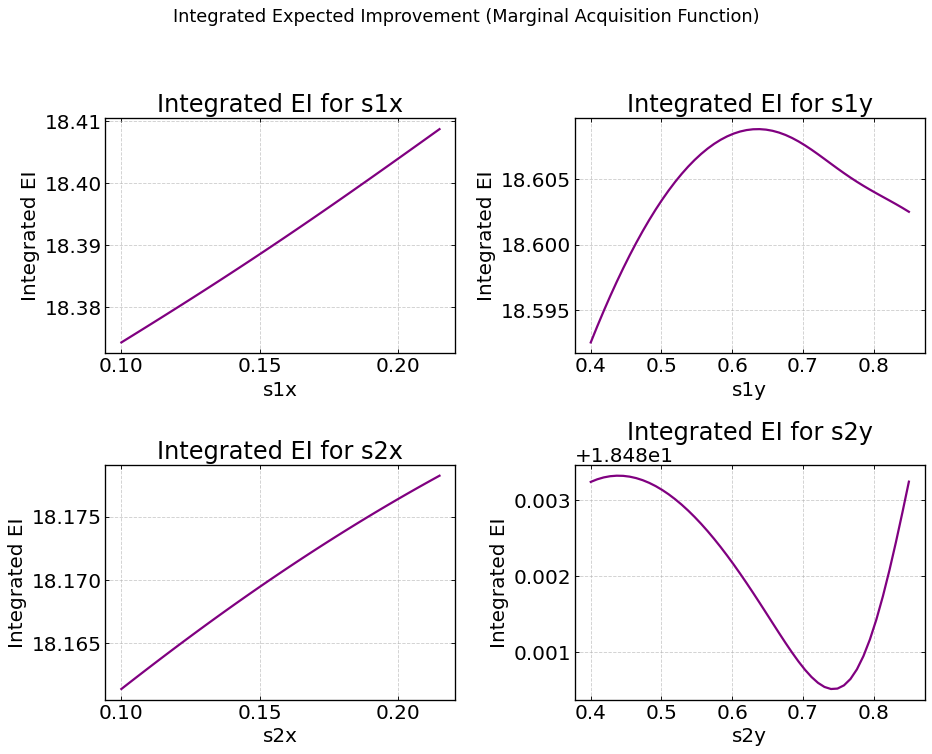

{'fig': <Figure size 960x800 with 4 Axes>,
 'axes': array([[<Axes: title={'center': 'Integrated EI for s1x'}, xlabel='s1x', ylabel='Integrated EI'>,
         <Axes: title={'center': 'Integrated EI for s1y'}, xlabel='s1y', ylabel='Integrated EI'>],
        [<Axes: title={'center': 'Integrated EI for s2x'}, xlabel='s2x', ylabel='Integrated EI'>,
         <Axes: title={'center': 'Integrated EI for s2y'}, xlabel='s2y', ylabel='Integrated EI'>]],
       dtype=object),
 'dim_ranges': [array([0.1       , 0.10234694, 0.10469388, 0.10704082, 0.10938776,
         0.11173469, 0.11408163, 0.11642857, 0.11877551, 0.12112245,
         0.12346939, 0.12581633, 0.12816327, 0.1305102 , 0.13285714,
         0.13520408, 0.13755102, 0.13989796, 0.1422449 , 0.14459184,
         0.14693878, 0.14928571, 0.15163265, 0.15397959, 0.15632653,
         0.15867347, 0.16102041, 0.16336735, 0.16571429, 0.16806122,
         0.17040816, 0.1727551 , 0.17510204, 0.17744898, 0.17979592,
         0.18214286, 0.1844898 , 0.

In [ ]:
# --- 5b. Visualize covariance matrix of the final model ---
plot.plot_covariance_matrix(final_gp_model["K"])
# --- 5c. Visualize PDPs and ICEs of the final model ---
plot.plot_pdp_ice(df_output, final_gp_model["Ky_inv"], final_gp_model["length_scale"], app_config.sim.param_names, app_config.sim.lower_bounds, app_config.sim.upper_bounds, )
# --- 5d. Visualize Integrated Expected Improvement ---
plot.plot_integrated_ei(df_output, final_gp_model["Ky_inv"], final_gp_model["length_scale"], app_config.sim.param_names, app_config.sim.lower_bounds, app_config.sim.upper_bounds, )